## Main Code

In [53]:
import numpy as np
import matplotlib.pyplot as plt


def generate_fcc_lattice ( n_cells , rho_star ):

    """
    Generates an FCC lattice of atoms .
    TASK :
    1. Calculate the box length L based on density (rho = N/V).
    2. Place 4 atoms in each of the n_cells ^3 unit cells .
    """
    L = (4 * n_cells ** 3 / rho_star) ** (1 / 3)
    a = L / n_cells 
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (a)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)

    return np.array(positions), L


# YOUR CODE HERE
def apply_minimum_image (pos_i , pos_j , L):
    """
    Calculates the shortest distance vector between two atoms .
    TASK : Use the rounding logic to ensure dx ,
    dy , and dz
    are between -L/2 and L/2.
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr

## Testing Code

### Testing lattice generation

In [62]:
n = 3
rho_star = 4
positions, L = generate_fcc_lattice(n, rho_star)
print(f"Box length L: {L}, Number of atoms: {len(positions)}, Cell parameter a: {L/n}")
print("Positions of atoms in the FCC lattice:")
print(positions[0:10])


Box length L: 3.0, Number of atoms: 108, Cell parameter a: 1.0
Positions of atoms in the FCC lattice:
[[0.  0.  0. ]
 [0.5 0.5 0. ]
 [0.5 0.  0.5]
 [0.  0.5 0.5]
 [0.  0.  1. ]
 [0.5 0.5 1. ]
 [0.5 0.  1.5]
 [0.  0.5 1.5]
 [0.  0.  2. ]
 [0.5 0.5 2. ]]


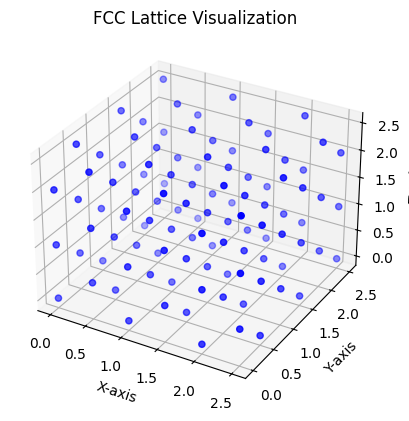

In [63]:
# Plot in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c='b', marker='o')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('FCC Lattice Visualization')
plt.show()

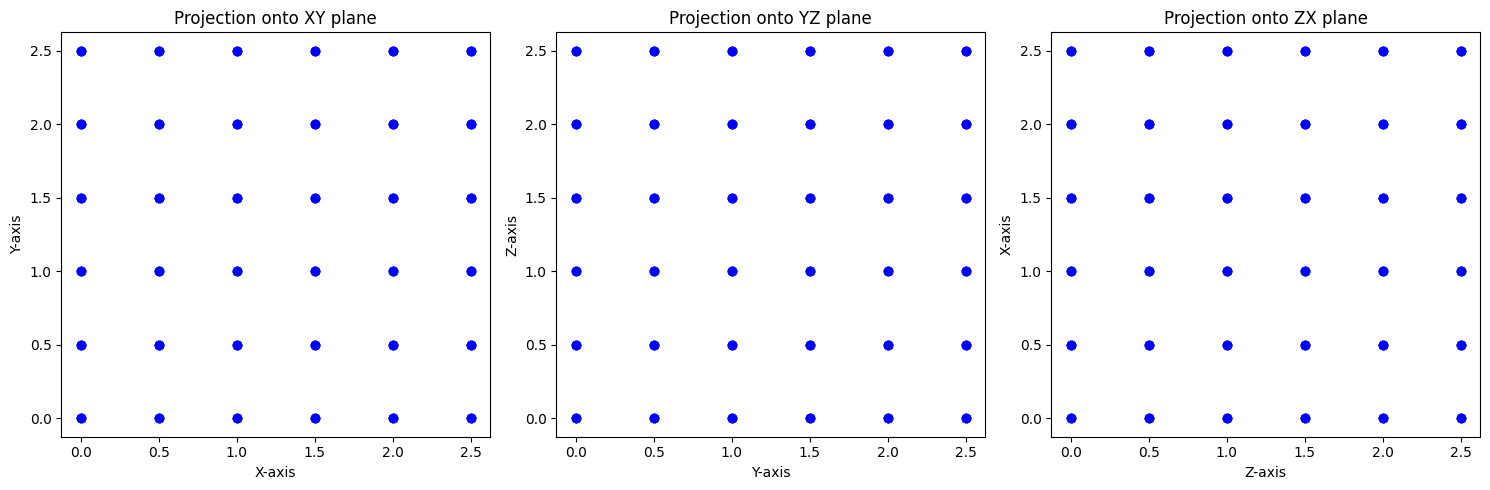

In [64]:
# Plot in 2D (projection onto XY, YZ, ZX plane)
fig = plt.figure(figsize=(15, 5))

# XY plane
ax1 = fig.add_subplot(131)
ax1.scatter(positions[:, 0], positions[:, 1], c='b', marker='o')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_title('Projection onto XY plane')

# YZ plane
ax2 = fig.add_subplot(132)
ax2.scatter(positions[:, 1], positions[:, 2], c='b', marker='o')
ax2.set_xlabel('Y-axis')
ax2.set_ylabel('Z-axis')
ax2.set_title('Projection onto YZ plane')

# ZX plane
ax3 = fig.add_subplot(133)
ax3.scatter(positions[:, 2], positions[:, 0], c='b', marker='o')
ax3.set_xlabel('Z-axis')
ax3.set_ylabel('X-axis')
ax3.set_title('Projection onto ZX plane')
plt.tight_layout()
plt.show()

### Testing Minimum Image Convention

Random test with big values

In [68]:
L = 2
pos_i = np.array([0.5, 7, 10])
pos_j = np.array([1.6, 118, 105])
dr = apply_minimum_image(pos_i, pos_j, L)
print("Box length L:", L)
print("Position of atom i:", pos_i)
print("Position of atom j:", pos_j)
print("Original distance vector between pos_i and pos_j:", pos_j - pos_i)
print(f"Shortest distance vector between pos_i and pos_j: {dr}\n")

initial_distance = np.linalg.norm(pos_j - pos_i)
shortest_distance = np.linalg.norm(dr)
max_allowed_distance = np.sqrt(3) * L / 2

print(f"Absolute (direct) distance between initial points: {initial_distance}")
print(f"Magnitude of shortest distance vector: {shortest_distance}")
print(f"sqrt(3)*L/2 = {max_allowed_distance}")
print(f"Is shortest distance < sqrt(3)*L/2?: {shortest_distance < max_allowed_distance}")

Box length L: 2
Position of atom i: [ 0.5  7.  10. ]
Position of atom j: [  1.6 118.  105. ]
Original distance vector between pos_i and pos_j: [  1.1 111.   95. ]
Shortest distance vector between pos_i and pos_j: [-0.9 -1.  -1. ]

Absolute (direct) distance between initial points: 146.10684446664365
Magnitude of shortest distance vector: 1.676305461424021
sqrt(3)*L/2 = 1.7320508075688772
Is shortest distance < sqrt(3)*L/2?: True


### Plotting Minimum Image Convention

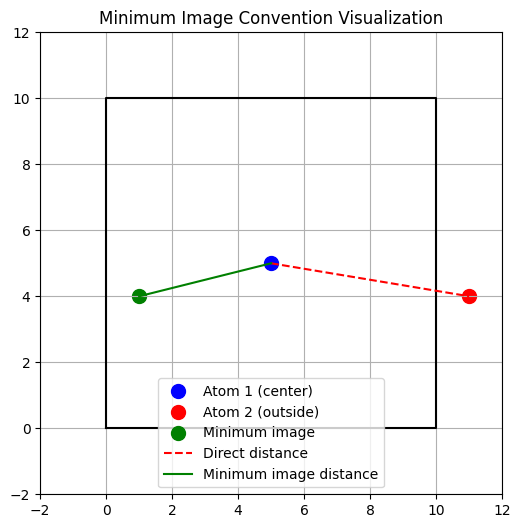

In [58]:
# Box length
L = 10.0

# Atom 1: center of the box
atom1 = np.array([L/2, L/2])

# Atom 2: outside the box
atom2 = np.array([11.0, 4.0])  # outside in x-direction

# Compute minimum image of atom2
atom2_image = apply_minimum_image(atom1, atom2, L) + atom1

# Plot
plt.figure(figsize=(6,6))

# Draw box
plt.plot([0, L, L, 0, 0], [0, 0, L, L, 0], 'k-')

# Plot atoms
plt.scatter(*atom1, color='blue', s=100, label='Atom 1 (center)')
plt.scatter(*atom2, color='red', s=100, label='Atom 2 (outside)')
plt.scatter(*atom2_image, color='green', s=100, label='Minimum image')

# Draw lines
plt.plot([atom1[0], atom2[0]], [atom1[1], atom2[1]], 'r--', label='Direct distance')
plt.plot([atom1[0], atom2_image[0]], [atom1[1], atom2_image[1]], 'g-', label='Minimum image distance')

# Formatting
plt.xlim(-2, L+2)
plt.ylim(-2, L+2)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.title("Minimum Image Convention Visualization")

plt.show()